# TimeOmni-VL 用户侧日前电价预测 — 全流程 Notebook

本 Notebook 复现 TimeOmni-VL 的核心数据流：
1. 数据加载与对齐
2. 数据清洗与样本生成
3. Bi-TSI 双向转换（TS2I / I2TS）
4. 理解任务与生成 CoT 构造
5. Mock Backbone 训练
6. 推理与评估

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 确保项目根目录在 PYTHONPATH 中
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 切换工作目录到项目根目录
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')
from timeomni_vl.config import ConfigManager
from timeomni_vl.data.pipeline import build_data_pipeline
from timeomni_vl.bitsi import RobustFidelityNormalizer, TS2IConverter, I2TSConverter, BiTSIValidator
from timeomni_vl.models import build_adapter
from timeomni_vl.tasks.understanding import UnderstandingTaskGenerator
from timeomni_vl.tasks.generation import GenerationTaskGenerator, GenerationEvaluator
from timeomni_vl.training.dataset import TSUMMDatasetBuilder
from timeomni_vl.inference.understanding import UnderstandingInferencer
from timeomni_vl.inference.generation import GenerationInferencer

print('Imports OK')

Working directory: D:\TimeOmni-VL
Imports OK


## 1. 加载配置

In [2]:
cfg = ConfigManager('configs/train.yaml')
data_cfg = cfg.get_data_config()
bitsi_cfg = cfg.get_bitsi_config()
model_cfg = cfg.get_model_config()
training_cfg = cfg.get_training_config()

print(f"backbone: {model_cfg.backbone}")
print(f"target variable: {data_cfg.target_variable}")
print(f"context days: {data_cfg.context_days}, forecast days: {data_cfg.forecast_days}")
print(f"image size: {bitsi_cfg.image_size}")

backbone: mock
target variable: 统一结算点电价临时结果
context days: 7, forecast days: 1
image size: 896


## 2. 数据加载、对齐、清洗与采样

In [3]:
pipeline = build_data_pipeline(data_cfg)
samples = pipeline.run()

print(f"\nTrain samples: {len(samples['train'])}")
print(f"Val samples: {len(samples['val'])}")
print(f"Test samples: {len(samples['test'])}")

sample = samples['train'][0]
print(f"\nSample context shape: {sample.context.shape}")
print(f"Sample target shape: {sample.target.shape}")
print(f"Sample task: {sample.task}")

2026-07-03 17:32:43,009 - timeomni_vl.data.pipeline - INFO - Loading CSV files...
2026-07-03 17:32:43,106 - timeomni_vl.data.loader - WARNING - Failed to load 数据集汇总表.csv: Dataset\数据集汇总表.csv: expected at least 10 columns, got 8
2026-07-03 17:32:43,208 - timeomni_vl.data.pipeline - INFO - Loaded 42 CSV files
2026-07-03 17:32:43,210 - timeomni_vl.data.pipeline - INFO - Aligning dates...
2026-07-03 17:32:43,214 - timeomni_vl.data.aligner - INFO - Aligning to target 用户侧日前出清发布\用户侧日前出清发布_统一结算点电价临时结果.csv with 25 dates
2026-07-03 17:32:46,307 - timeomni_vl.data.pipeline - INFO - Aligned dataframe shape: (2400, 42)
2026-07-03 17:32:46,307 - timeomni_vl.data.pipeline - INFO - Cleaning data...
2026-07-03 17:32:46,307 - timeomni_vl.data.cleaner - INFO - Dropped variables with high missing ratio: ['分省可再生能源发电能力预测_发电能力_发电能力(MW)', '实际受电情况_实际发布电力_实际发布电力(MW)', '实际系统负荷_实际发布电力_实际发布电力(MW)', '用户侧日前出清发布_统一结算点电价最终结果']
2026-07-03 17:32:46,324 - timeomni_vl.data.pipeline - INFO - Cleaned dataframe shape: (2400, 

## 3. Bi-TSI：时间序列 ⇄ 图像

Source TS-image size: (448, 421)


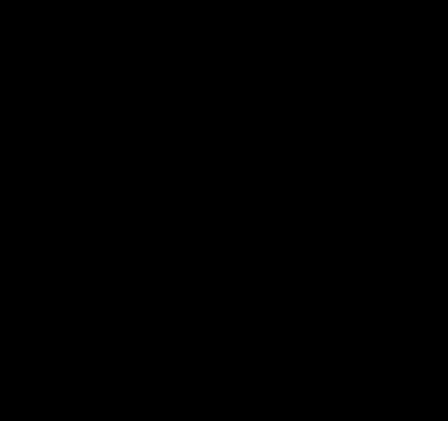

In [4]:
rfn = RobustFidelityNormalizer(
    alpha=bitsi_cfg.alpha,
    c_mad=bitsi_cfg.c_mad,
    kappa=bitsi_cfg.kappa
)
ts2i = TS2IConverter(
    frequency=data_cfg.frequency,
    image_size=448,  # 使用较小尺寸便于 Notebook 快速验证
    color_map=bitsi_cfg.color_map
)
i2ts = I2TSConverter(
    frequency=data_cfg.frequency,
    image_size=448
)

ctx_norm, stats = rfn.fit_transform(sample.context)
src_image = ts2i.convert(ctx_norm)

print(f"Source TS-image size: {src_image.size}")
src_image

### 3.1 Round-trip 验证

In [5]:
validator = BiTSIValidator(rfn, ts2i, i2ts)
metrics = validator.validate(sample.context[:96*3])  # 用 3 天数据验证
print(f"Round-trip metrics: {metrics}")

Round-trip metrics: {'mae': 1632.3062744140625, 'rmse': 3289.680908203125, 'max_error': 17954.3046875}


## 4. 理解任务生成

In [6]:
qa_gen = UnderstandingTaskGenerator(
    frequency=data_cfg.frequency,
    image_size=448
)
qas = qa_gen.generate_all(sample)

for qa in qas:
    print(f"\n{qa['task_id']}: {qa['question']}")
    print(f"  CoT: {qa['cot'][:80]}...")
    print(f"  Answer: {qa['answer']}")


qa1: How many variables are encoded in the TS-image?
  CoT: The TS-image contains 42 horizontal color bands, each representing one variable....
  Answer: 42

qa2: What is the vertical range of variable 23?
  CoT: Variable 23 occupies band 23 from y=230 to y=240....
  Answer: [230, 240]

qa3: What is the bounding box of cycle 0 for variable 23?
  CoT: Cycle 0 spans x=0 to x=64....
  Answer: [0, 64]

qa4: Which cycle has a higher average value, cycle 0 or cycle 1?
  CoT: Cycle 0 mean=303.83, cycle 1 mean=333.39....
  Answer: 1

qa5: Which time points in variable 23 exceed 18.0?
  CoT: Detected 672 points above threshold 18.0....
  Answer: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90,

## 5. 生成 CoT 与训练数据集构造

In [7]:
gen_gen = GenerationTaskGenerator(
    frequency=data_cfg.frequency,
    context_days=data_cfg.context_days,
    forecast_days=data_cfg.forecast_days
)
cot = gen_gen.generate_cot(qas)
print('Generated CoT:')
print(cot)

dataset_builder = TSUMMDatasetBuilder(data_cfg, bitsi_cfg)
train_dataset = dataset_builder.build(samples['train'][:3])
print(f"\nBuilt {len(train_dataset)} training items")
print(f"Keys: {list(train_dataset[0].keys())}")

Generated CoT:
qa1: The TS-image contains 42 horizontal color bands, each representing one variable.
qa2: Variable 23 occupies band 23 from y=230 to y=240.
qa3: Cycle 0 spans x=0 to x=64.
qa4: Cycle 0 mean=303.83, cycle 1 mean=333.39.
qa5: Detected 672 points above threshold 18.0.
qa6: Peak at point 83, trough at point 57.
Forecast: predict the next 1 day(s) (96 points) of electricity price.

Built 3 training items
Keys: ['image_src', 'image_tgt', 'instruction', 'cot', 'answer', 'task', 'stats']


## 6. 加载 Backbone 并训练（Mock）

In [8]:
adapter = build_adapter(model_cfg.backbone)
adapter.load(model_cfg.model_path, model_cfg.device)
print(f"Adapter loaded: {type(adapter).__name__}")

# 模拟训练循环
history = []
for epoch in range(1, training_cfg.num_epochs + 1):
    total_loss = 0.0
    for item in train_dataset:
        metrics = adapter.train_step(item)
        total_loss += metrics['loss_total']
    avg_loss = total_loss / len(train_dataset)
    history.append(avg_loss)
    print(f"Epoch {epoch}/{training_cfg.num_epochs}, loss: {avg_loss:.4f}")

Adapter loaded: MockAdapter
Epoch 1/2, loss: 0.8000
Epoch 2/2, loss: 0.8000


## 7. 推理：理解与生成

In [9]:
# 7.1 理解推理
understand_inferencer = UnderstandingInferencer(adapter)
understand_result = understand_inferencer.infer(
    src_image,
    question='How many variables are encoded in this TS-image?'
)
print('Understanding result:')
print(understand_result)

Understanding result:
{'raw': '<think>Mock reasoning</think> Mock answer.', 'cot': 'Mock reasoning', 'answer': 'Mock answer.'}


In [10]:
# 7.2 生成推理
gen_inferencer = GenerationInferencer(adapter, i2ts, use_cot=True)
forecast_result = gen_inferencer.forecast(
    source_image=src_image,
    instruction='Predict the next day electricity price.',
    n_vars=sample.context.shape[1],
    target_length=data_cfg.forecast_days * data_cfg.points_per_day,
    stats=stats
)

print(f"CoT: {forecast_result['cot'][:100]}...")
print(f"Predicted values shape: {forecast_result['predicted_values'].shape}")
print(f"Predicted values range: [{forecast_result['predicted_values'].min():.2f}, {forecast_result['predicted_values'].max():.2f}]")

CoT: Mock reasoning...
Predicted values shape: (96, 42)
Predicted values range: [0.00, 0.00]


## 8. 评估与可视化

Evaluation metrics:
{'mae': 1280.520751953125, 'rmse': 2127.345703125, 'nmape': 1.0000014305114746, 'direction': 0.7789473684210526}


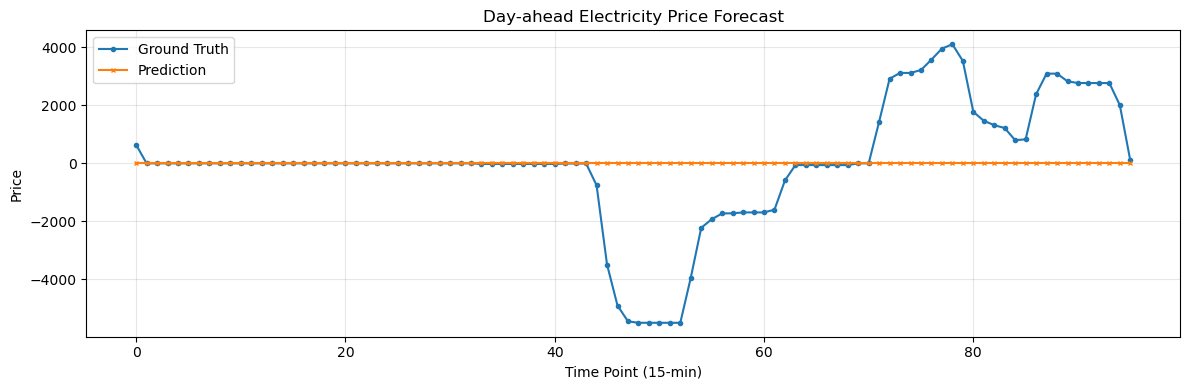

In [11]:
# 提取目标变量索引
target_idx = 0  # 默认第一个变量为目标
for i, name in enumerate(train_dataset[0].get('variable_names', [])):
    if data_cfg.target_variable in name:
        target_idx = i
        break

pred = forecast_result['predicted_values']
if pred.ndim > 1:
    pred = pred[:, target_idx]
ref = sample.target[:len(pred), target_idx]

evaluator = GenerationEvaluator(metrics=['mae', 'rmse', 'nmape', 'direction'])
eval_metrics = evaluator.evaluate(pred, ref)
print('Evaluation metrics:')
print(eval_metrics)

plt.figure(figsize=(12, 4))
plt.plot(ref, label='Ground Truth', marker='o', markersize=3)
plt.plot(pred, label='Prediction', marker='x', markersize=3)
plt.title('Day-ahead Electricity Price Forecast')
plt.xlabel('Time Point (15-min)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 结果说明

- 当前使用 `MockAdapter`，理解输出和生成图像均为占位结果。
- 真实训练需接入 `Bagel-7B` 或 `Janus-Pro` 等 UMM backbone。
- 由于目标变量仅 25 天有效数据，训练样本稀少，真实训练时建议增加数据增强与滚动窗口。